## 7. Visualisation & Reporting  

### 7.1 Training & Validation Loss (Neural Network)

To assess the learning progress of the neural network, a loss curve was plotted.  
To help determine whether the model was performing well.

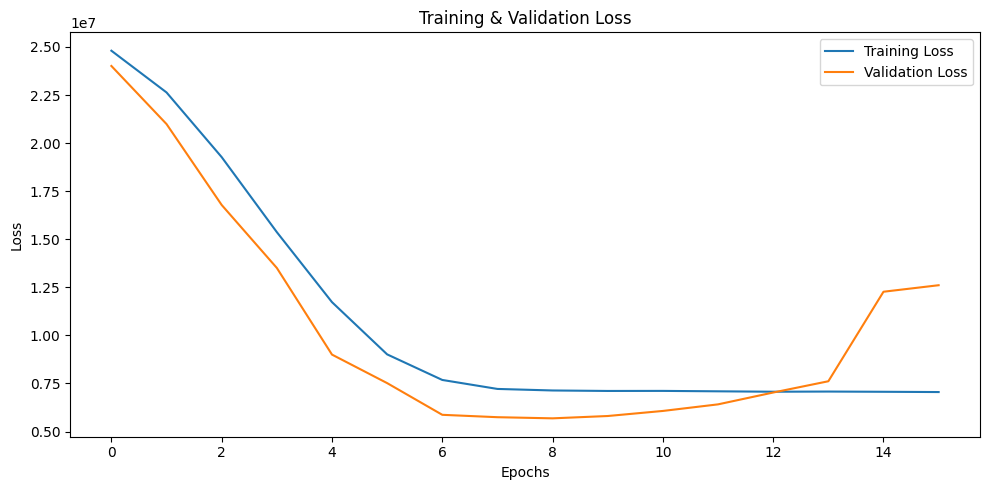

In [95]:
# plot training vs validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

Findings:

* Early stopping worked, but the model still overfits slightly after epoch 7.

* Validation loss starts increasing, meaning the model is memorising the training data instead of generalising.

* We could try reducing the number of epochs or adding more dropout/regularisation.

### 7.2 Feature Importance (Random Forest)

The feature importance scores were extracted from the trained Random Forest model to identify the most influential factors in predicting house prices.

Key Observations:
* Floor Area (SqM) is the most important feature, having the strongest correlation with price.
* Longitude and Latitude play a significant role, highlighting the impact of location.
* Number of rooms (bedrooms, bathrooms, living rooms) has a relatively lower impact.

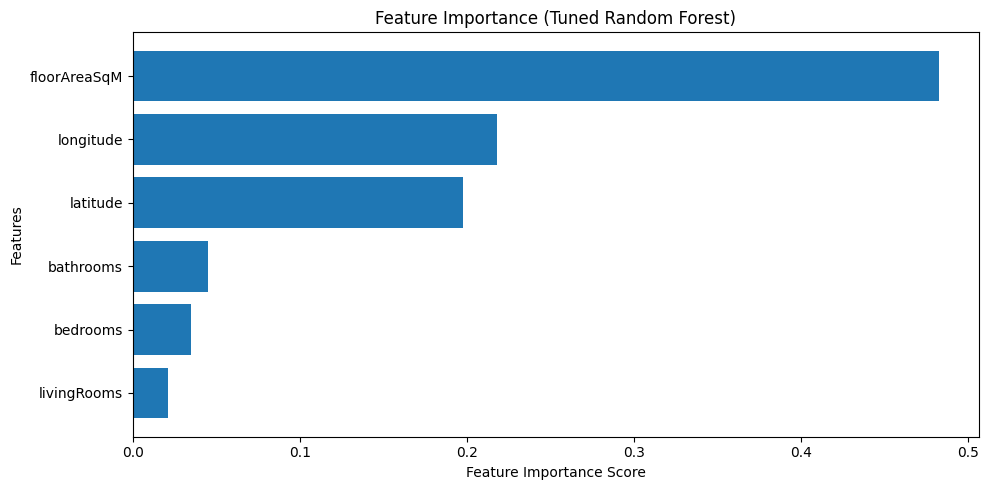

In [96]:
# get feature importance from best model
feature_importance = best_rf.feature_importances_
features = X_train.columns

# sort features by importance
sorted_idx = np.argsort(feature_importance)

# plot feature importance
plt.figure(figsize=(10, 5))
plt.barh(np.array(features)[sorted_idx], feature_importance[sorted_idx])
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance (Tuned Random Forest)')
plt.tight_layout()
plt.show()


### 7.3 Model Performance Comparison

To compare the effectiveness of different models, their Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score were visualised.

Key Observations:
* Random Forest (Tuned) significantly outperforms all other models.
* XGBoost performs well but lags behind Random Forest.
* Neural Network underperforms, likely due to overfitting and lack of feature engineering.

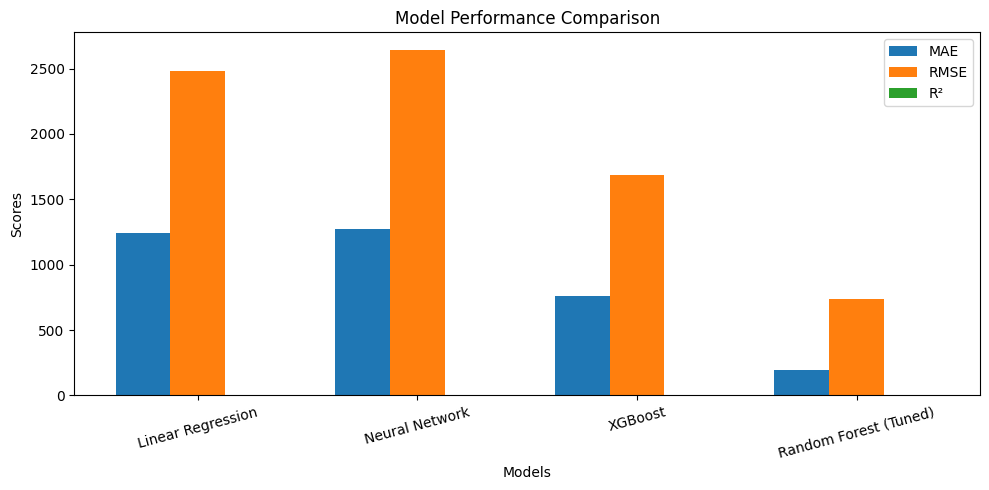

In [2]:
# define model names and their scores
models = ['Linear Regression', 'Neural Network', 'XGBoost', 'Random Forest (Tuned)']
mae_scores = [1244.16, 1270.10, 763.07, 197.50]
rmse_scores = [2485.01, 2644.70, 1683.82, 738.97]
r2_scores = [0.4917, 0.4823, 0.7901, 0.9551]

# plot model comparison
fig, ax = plt.subplots(figsize=(10, 5))

bar_width = 0.25
x = np.arange(len(models))

# plot each metric
ax.bar(x, mae_scores, bar_width, label='MAE')
ax.bar(x + bar_width, rmse_scores, bar_width, label='RMSE')
ax.bar(x + 2 * bar_width, r2_scores, bar_width, label='R²')

# label formatting
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + bar_width)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.tight_layout()
plt.show()

The green bars (R² score) are missing because the values for R² are too small relative to MAE and RMSE, making them nearly invisible.

Updated Code (with Secondary Y-Axis)

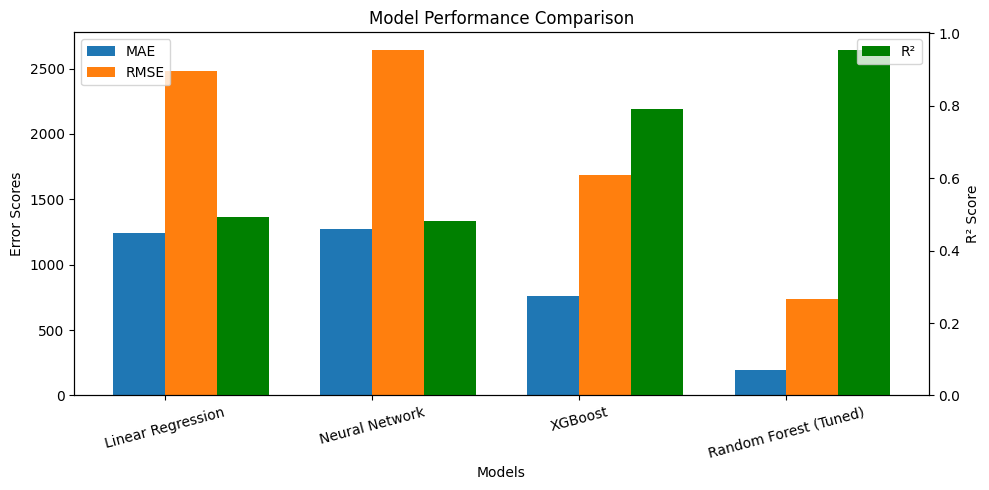

In [3]:
# define model names and their scores
models = ['Linear Regression', 'Neural Network', 'XGBoost', 'Random Forest (Tuned)']
mae_scores = [1244.16, 1270.10, 763.07, 197.50]
rmse_scores = [2485.01, 2644.70, 1683.82, 738.97]
r2_scores = [0.4917, 0.4823, 0.7901, 0.9551]  # R² values

# plot model comparison with dual y-axis
fig, ax1 = plt.subplots(figsize=(10, 5))

bar_width = 0.25
x = np.arange(len(models))

# primary y-axis (MAE & RMSE)
ax1.bar(x, mae_scores, bar_width, label='MAE')
ax1.bar(x + bar_width, rmse_scores, bar_width, label='RMSE')
ax1.set_xlabel('Models')
ax1.set_ylabel('Error Scores')
ax1.set_title('Model Performance Comparison')

# set x-axis ticks and labels
ax1.set_xticks(x + bar_width / 2)
ax1.set_xticklabels(models, rotation=15)

# secondary y-axis (R²)
ax2 = ax1.twinx()
ax2.bar(x + 2 * bar_width, r2_scores, bar_width, label='R²', color='green')
ax2.set_ylabel('R² Score')

# legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 7.4 Final Reporting

### Key Takeaways

The model comparison showed that **Random Forest (Tuned)** significantly outperformed other models, achieving:  

- **MAE:** 197.50  

- **RMSE:** 738.97  

- **R²:** 0.9551  

The **feature importance analysis** revealed that:

- **Floor Area (SqM) is the most influential factor** in determining house prices.  

- **Location (longitude, latitude) also plays a key role.**  

- Other features like **bedrooms, bathrooms, and living rooms have a smaller impact.**  